In [2]:
import pandas as pd

df = pd.read_csv('../data/employee_attrition_clean.csv')  

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

new_num_cols = [
    'Years_At_Company', 'Age', 'Performance_Score', 'Education_Level',

    'Department_Finance', 'Department_HR',

    'Job_Role_Marketing Manager', 'Job_Role_QA Engineer', 'Job_Role_Recruiter',
    'Job_Role_Sales Executive', 'Job_Role_Sales Manager', 'Job_Role_Senior Engineer',
    'Job_Role_Software Engineer',
]

In [4]:
X_features = df[new_num_cols]
y = df[['Monthly_Income']]
model = LinearRegression()
model.fit(X_features, y)
y_pred = model.predict(X_features)

In [5]:
df['Monthly_Income_Predictions'] = y_pred
df['Subtraction'] = df['Monthly_Income'] - df['Monthly_Income_Predictions']

In [6]:
scaler = StandardScaler()
df['Subtraction_scaled'] = scaler.fit_transform(df[['Subtraction']])

In [7]:
#flag employees with high difference
flagged = df[df['Subtraction_scaled'].abs() > 2].sort_values('Subtraction_scaled', ascending=False)
print(f"Flagged {len(flagged)} employees")
print(flagged[['Monthly_Income', 'Monthly_Income_Predictions', 'Subtraction', 'Subtraction_scaled']])

Flagged 38 employees
     Monthly_Income  Monthly_Income_Predictions  Subtraction  \
494        9448.096                 4101.506532  5346.589468   
872        8229.910                 5180.877948  3049.032052   
34         5928.328                 3225.946346  2702.381654   
153        7384.530                 4760.323921  2624.206079   
877        6590.560                 4159.084948  2431.475052   
915        7875.630                 5467.689311  2407.940689   
255        7893.310                 5597.137304  2296.172696   
93         8960.840                 6671.165554  2289.674446   
31         9446.360                 7366.156244  2080.203756   
890        7729.730                 5658.783796  2070.946204   
920        8202.950                 6144.058196  2058.891804   
409        7626.830                 5572.079927  2054.750073   
412        8564.480                 6586.662536  1977.817464   
43         7016.190                 5195.023502  1821.166498   
779        6464.110

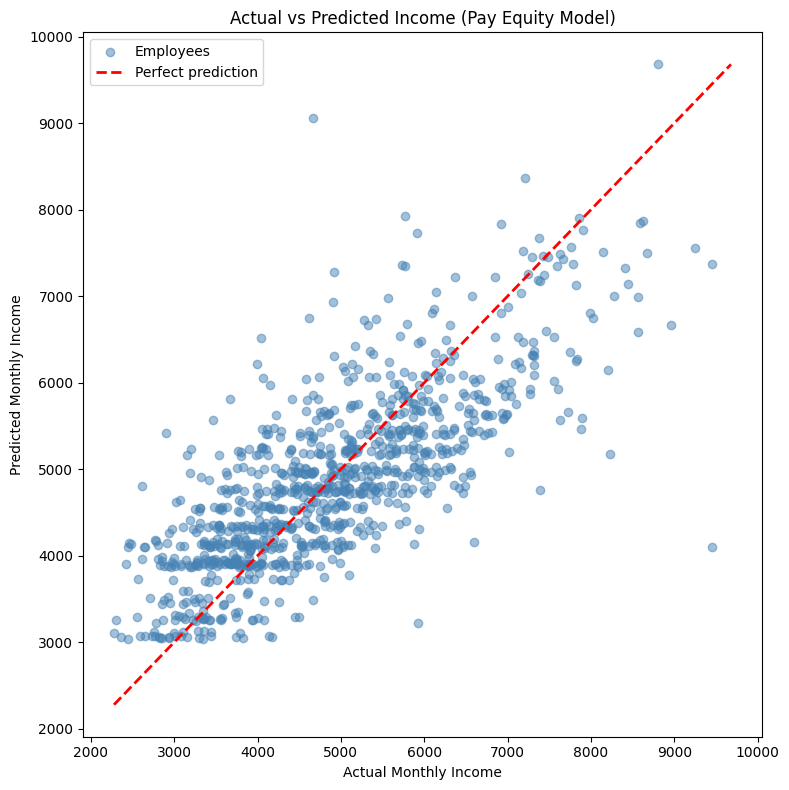

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# Scatter: actual vs predicted
plt.scatter(df['Monthly_Income'], df['Monthly_Income_Predictions'],
            alpha=0.5, color='steelblue', label='Employees')

# Reference line: where actual == predicted (perfect prediction)
min_val = min(df['Monthly_Income'].min(), df['Monthly_Income_Predictions'].min())
max_val = max(df['Monthly_Income'].max(), df['Monthly_Income_Predictions'].max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual Monthly Income')
plt.ylabel('Predicted Monthly Income')
plt.title('Actual vs Predicted Income (Pay Equity Model)')
plt.legend()
plt.tight_layout()
plt.show()